<!-- @format -->

# Adult Income Prediction

## 1. Exploratory Data Analysis (EDA)

Phần này trình bày tổng quan dữ liệu, phân phối target, và một số đặc trưng quan trọng trước khi thực hiện preprocessing.

### 1.1. Load dataset

Dataset được tải từ nguồn công khai trên GitHub để notebook có thể chạy trực tiếp trên Google Colab.


In [ ]:
# [EDA 1.1] Import module và load dataset
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import modules.eda as eda

url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = eda.load_data(url)

Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-pe

<!-- @format -->

### 1.2. Dataset overview

Phần này kiểm tra cấu trúc tổng quát của dữ liệu, bao gồm kiểu dữ liệu, thống kê mô tả, và phân loại sơ bộ giữa các cột số và cột phân loại.


In [2]:
# [EDA 1.2] Tổng quan cấu trúc dataset và phân loại cột
eda.dataset_overview(df)
num_cols, cat_cols = eda.get_column_types(df)

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Numerical Summary ===
                age       

<!-- @format -->

### 1.3. Missing value inspection

Trước khi xử lý dữ liệu, cần kiểm tra missing value theo chuẩn `NaN` và quan sát các giá trị bất thường trong các cột phân loại.


=== Missing values (NaN) ===
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

=== '?' count per column ===
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

=== '?' percentage per column (%) ===
age                0.00
workclass          5.73
fnlwgt             0.00
education          0.00
educational-num    0.00
marital-status     0.00
occupation         5.75
relationship       0.00
race     

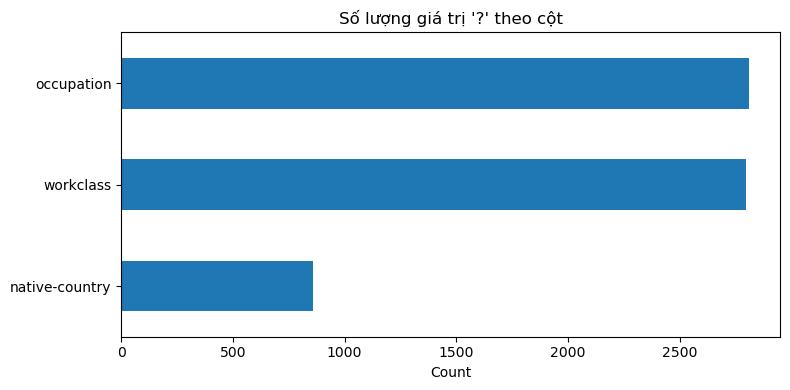

In [3]:
# [EDA 1.3] Kiểm tra missing value (NaN chuẩn và ký hiệu '?')
eda.check_missing_values(df)
eda.plot_missing_summary(df)

In [4]:
# [EDA 1.3] Kiểm tra giá trị phổ biến trong từng cột categorical
eda.inspect_categorical_values(df, cat_cols)


Column: workclass  |  unique: 9
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Column: education  |  unique: 16
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

Column: marital-status  |  unique: 7
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

Column: occupation  |  unique: 15
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-manageri

<!-- @format -->

Kết quả cho thấy một số cột categorical xuất hiện giá trị `?`, cho thấy dữ liệu thiếu đang được mã hóa dưới dạng chuỗi thay vì `NaN`.

Vì vậy, ở bước preprocessing, nhóm sẽ cần chuẩn hóa các giá trị này về dạng missing value chuẩn trước khi thực hiện imputation.


<!-- @format -->

### 1.4. Target distribution

Phần này kiểm tra phân phối của biến mục tiêu `income` để đánh giá mức độ cân bằng giữa các lớp.


Unique values: ['<=50K' '>50K']

Class counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class percentages (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


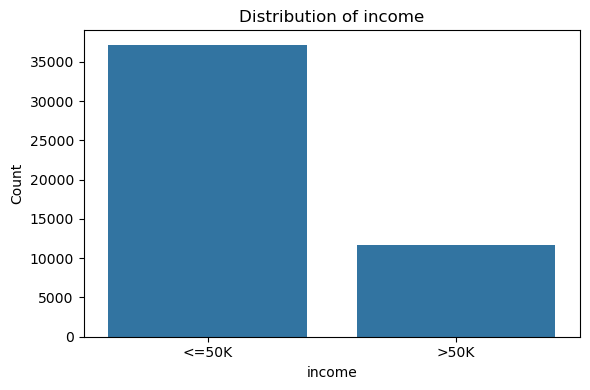

In [5]:
# [EDA 1.4] Phân phối biến mục tiêu income
eda.plot_target_distribution(df, target_col='income')

<!-- @format -->

### 1.5. Categorical features by target

Phân tích một số biến phân loại tiêu biểu gồm `education`, `occupation`, và `marital-status` để quan sát sự khác biệt phân phối giữa hai nhóm thu nhập.



=== education by income (proportion) ===
income        <=50K   >50K
education                 
10th          0.937  0.063
11th          0.949  0.051
12th          0.927  0.073
1st-4th       0.968  0.032
5th-6th       0.947  0.053
7th-8th       0.935  0.065
9th           0.946  0.054
Assoc-acdm    0.742  0.258
Assoc-voc     0.747  0.253
Bachelors     0.587  0.413
Doctorate     0.274  0.726
HS-grad       0.841  0.159
Masters       0.451  0.549
Preschool     0.988  0.012
Prof-school   0.260  0.740
Some-college  0.810  0.190


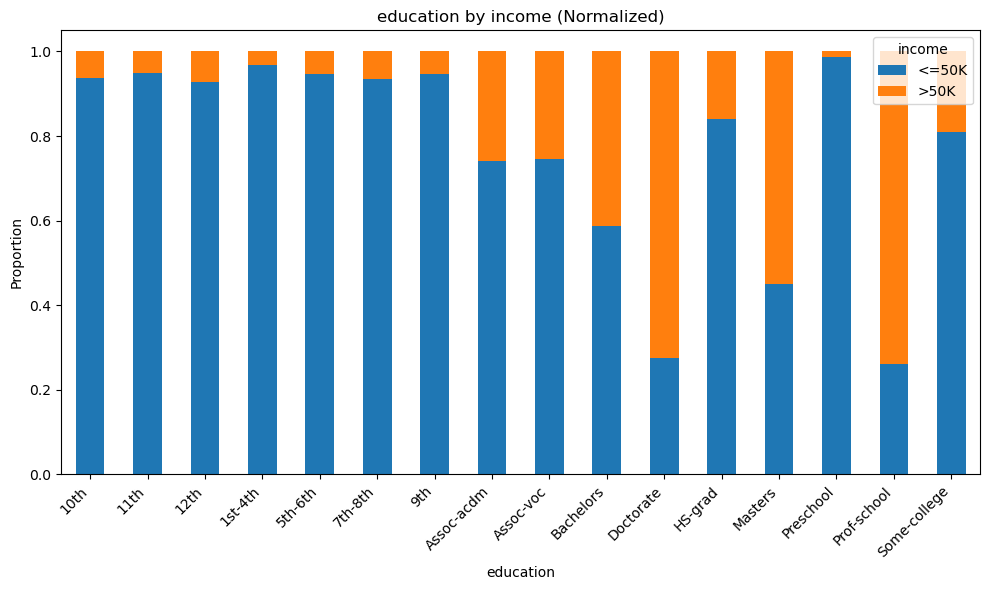


=== occupation by income (proportion) ===
income             <=50K   >50K
occupation                     
?                  0.906  0.094
Adm-clerical       0.863  0.137
Armed-Forces       0.667  0.333
Craft-repair       0.774  0.226
Exec-managerial    0.522  0.478
Farming-fishing    0.884  0.116
Handlers-cleaners  0.933  0.067
Machine-op-inspct  0.877  0.123
Other-service      0.959  0.041
Priv-house-serv    0.988  0.012
Prof-specialty     0.549  0.451
Protective-serv    0.687  0.313
Sales              0.732  0.268
Tech-support       0.710  0.290
Transport-moving   0.796  0.204


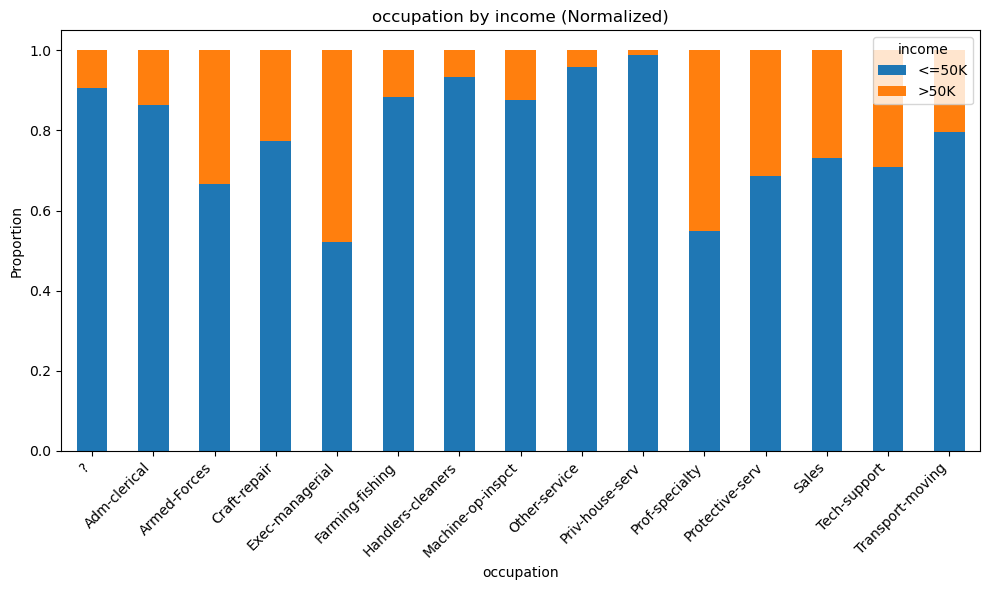


=== marital-status by income (proportion) ===
income                 <=50K   >50K
marital-status                     
Divorced               0.899  0.101
Married-AF-spouse      0.622  0.378
Married-civ-spouse     0.554  0.446
Married-spouse-absent  0.908  0.092
Never-married          0.955  0.045
Separated              0.935  0.065
Widowed                0.916  0.084


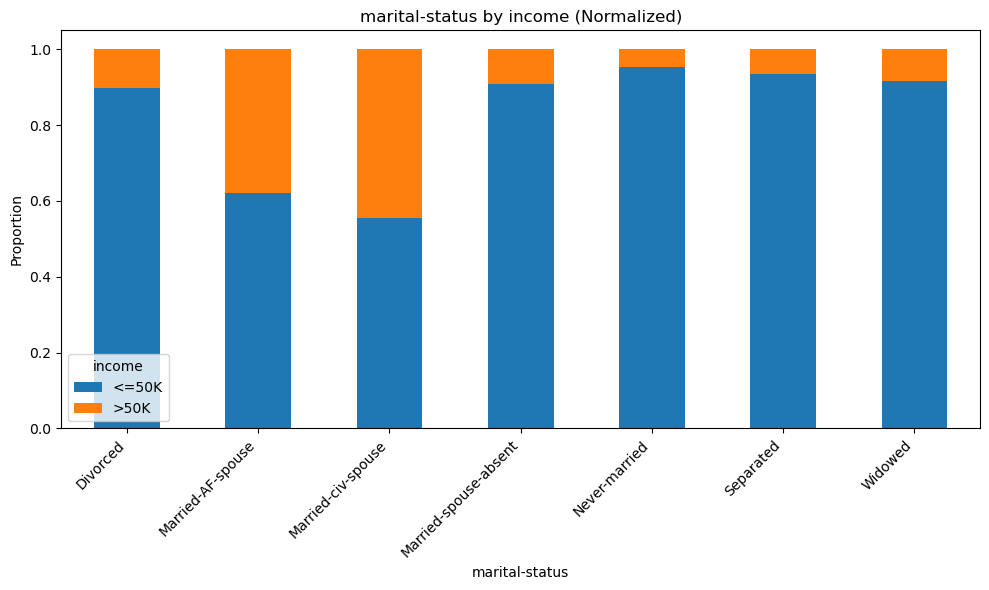

In [6]:
# [EDA 1.5] Crosstab tỷ lệ và stacked bar chart cho các cột categorical tiêu biểu
# Hàm plot_categorical_by_target đã bao gồm cả print crosstab và vẽ biểu đồ
selected_cat_cols = ['education', 'occupation', 'marital-status']
eda.plot_categorical_by_target(df, selected_cat_cols, target_col='income')

<!-- @format -->

Để quan sát rõ hơn sự khác biệt giữa hai nhóm thu nhập trong từng category, nhóm sử dụng bảng tỷ lệ theo hàng và biểu đồ cột chồng chuẩn hóa.


<!-- @format -->

### 1.6. Numerical features by target

Phần này sử dụng boxplot để so sánh phân phối của một số biến số theo `income`.


                age  hours-per-week  educational-num
count  48842.000000    48842.000000     48842.000000
mean      38.643585       40.422382        10.078089
std       13.710510       12.391444         2.570973
min       17.000000        1.000000         1.000000
25%       28.000000       40.000000         9.000000
50%       37.000000       40.000000        10.000000
75%       48.000000       45.000000        12.000000
max       90.000000       99.000000        16.000000


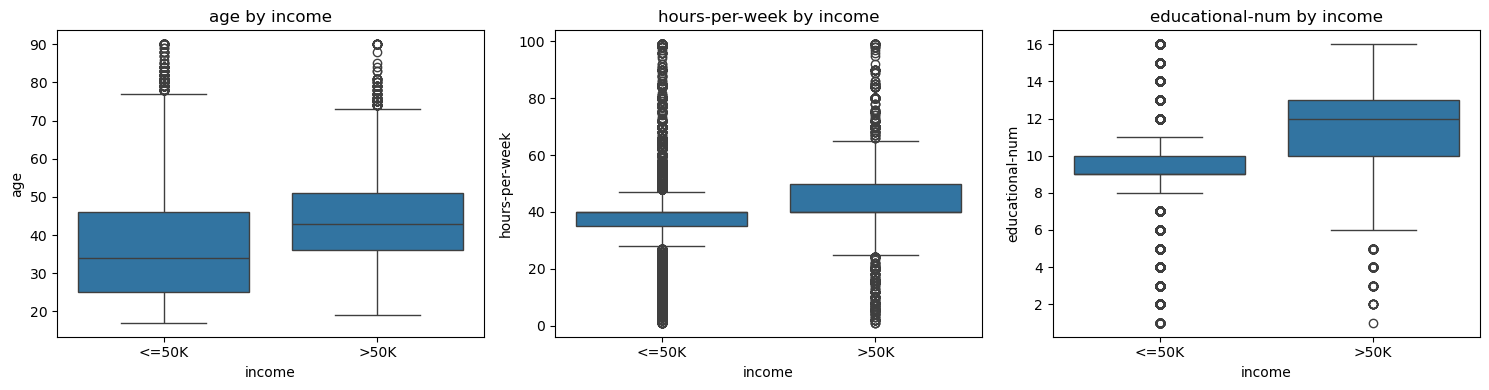

In [7]:
# [EDA 1.6] Boxplot các biến số tiêu biểu theo income
selected_num_cols = ['age', 'hours-per-week', 'educational-num']
eda.plot_numerical_by_target(df, selected_num_cols, target_col='income')

<!-- @format -->

### 1.7. Distribution analysis for `capital-gain`

Phần này tập trung vào `capital-gain` vì biến này có phân phối lệch mạnh, tỷ lệ giá trị bằng 0 rất cao và xuất hiện một số giá trị lớn bất thường.


=== capital-gain ===
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Zero values : 44807 (91.74%)
Non-zero    : 4035 (8.26%)

Proportion of non-zero capital-gain by income:
capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


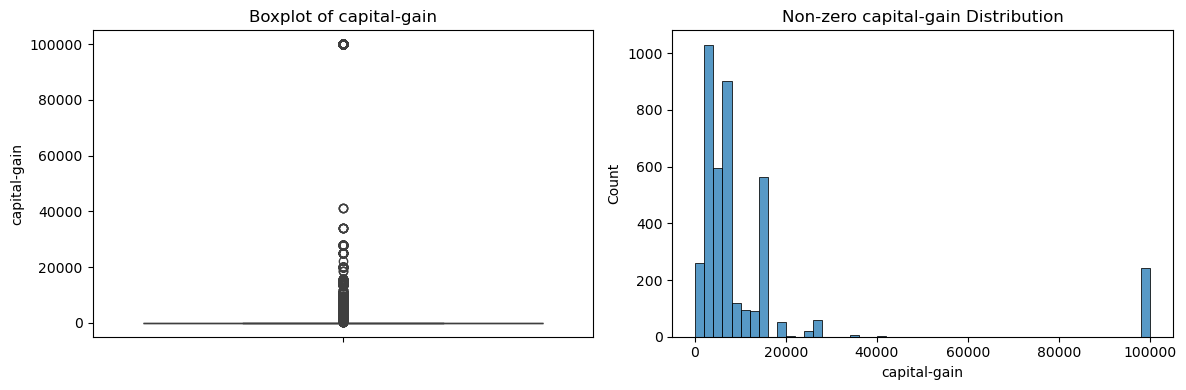

In [8]:
# [EDA 1.7] Phân tích phân phối và mối liên hệ với target của capital-gain
eda.analyze_capital_feature(df, 'capital-gain', target_col='income')

<!-- @format -->

Do phần lớn giá trị bằng `0`, nhóm chỉ trực quan hóa phân phối của các giá trị `capital-gain > 0` để quan sát rõ hơn phần đuôi phân phối.


<!-- @format -->

### 1.8. Correlation heatmap

Phần này trực quan hóa ma trận tương quan giữa các numerical features để quan sát mức độ liên hệ tuyến tính giữa các biến số.


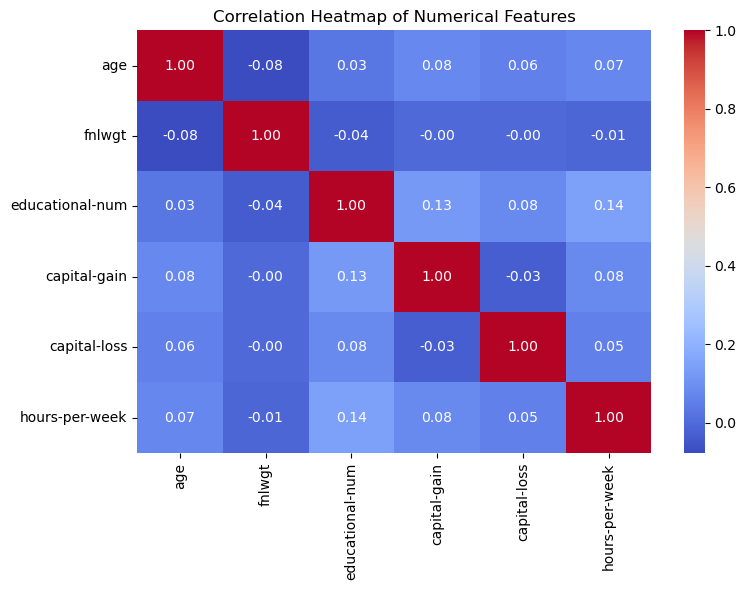

In [9]:
# [EDA 1.8] Ma trận tương quan giữa các numerical features
eda.plot_correlation_heatmap(df, num_cols)

<!-- @format -->

Kết quả cho thấy phần lớn numerical features chỉ có tương quan tuyến tính yếu với nhau, chưa xuất hiện cặp biến số nào có tương quan quá cao.


<!-- @format -->

### 1.9. Relationship between `education` and `educational-num`

Phần này kiểm tra xem hai cột `education` và `educational-num` có đang biểu diễn cùng một thông tin hay không.


In [10]:
# [EDA 1.9] Kiểm tra trùng lặp thông tin giữa education và educational-num
eda.check_education_redundancy(df)

Mapping between education and educational-num:
       education educational-num
0           10th             [6]
1           11th             [7]
2           12th             [8]
3        1st-4th             [2]
4        5th-6th             [3]
5        7th-8th             [4]
6            9th             [5]
7     Assoc-acdm            [12]
8      Assoc-voc            [11]
9      Bachelors            [13]
10     Doctorate            [16]
11       HS-grad             [9]
12       Masters            [14]
13     Preschool             [1]
14   Prof-school            [15]
15  Some-college            [10]


<!-- @format -->

Kết quả cho thấy mỗi mức của `education` tương ứng với đúng một giá trị của `educational-num`. Điều này cho thấy hai cột gần như mang cùng nội dung thông tin, chỉ khác cách biểu diễn.


<!-- @format -->

### 1.10. Additional analysis of `capital-gain`

Ngoài phân phối và outlier, nhóm kiểm tra thêm mối liên hệ giữa `capital-gain` và target `income`.


capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


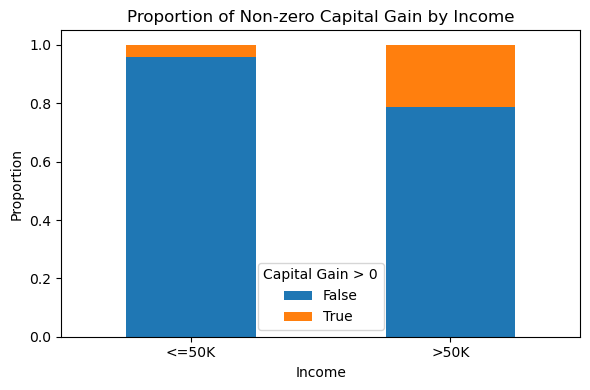

In [11]:
# [EDA 1.10] So sánh tỷ lệ capital-gain > 0 giữa hai nhóm income
import pandas as pd
import matplotlib.pyplot as plt

capital_gain_flag = pd.crosstab(
    df['income'],
    df['capital-gain'] > 0,
    normalize='index'
).round(3)
print(capital_gain_flag)

capital_gain_flag.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Proportion of Non-zero Capital Gain by Income')
plt.xlabel('Income')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Capital Gain > 0')
plt.tight_layout()
plt.show()

<!-- @format -->

Kết quả cho thấy tỷ lệ quan sát có `capital-gain > 0` ở nhóm `>50K` cao hơn đáng kể so với nhóm `<=50K`.


<!-- @format -->

Biểu đồ củng cố nhận định rằng `capital-gain` có thể là một biến hữu ích cho bài toán phân loại thu nhập, dù bản thân biến này có phân phối rất lệch.


<!-- @format -->

### 1.11. Additional check for `capital-loss`

Ngoài `capital-gain`, nhóm kiểm tra thêm `capital-loss` để đánh giá xem biến này có nên bị loại bỏ ngay ở bước preprocessing hay không.


=== capital-loss ===
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Zero values : 46560 (95.33%)
Non-zero    : 2282 (4.67%)

Proportion of non-zero capital-loss by income:
capital-loss  False  True 
income                    
<=50K         0.969  0.031
>50K          0.902  0.098


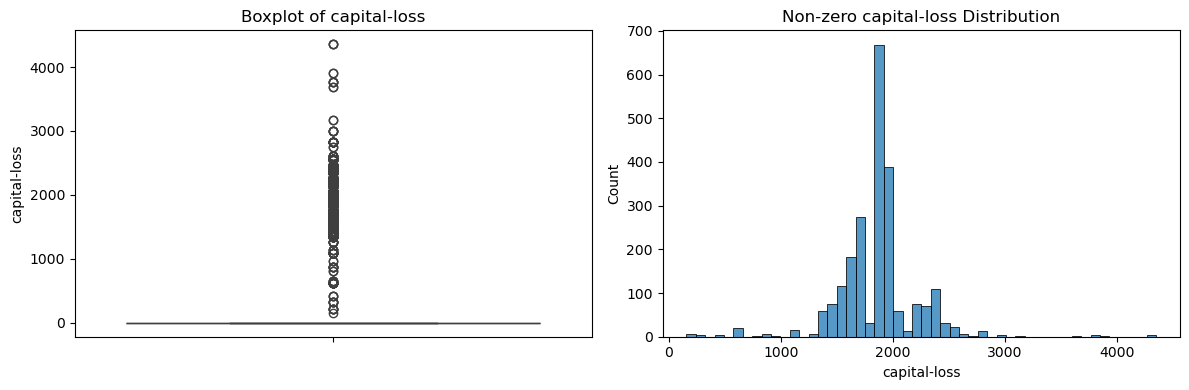

In [12]:
# [EDA 1.11] Phân tích capital-loss trước khi quyết định có loại bỏ hay không
eda.analyze_capital_feature(df, 'capital-loss', target_col='income')

<!-- @format -->

Kết quả cho thấy `capital-loss` có tỷ lệ giá trị bằng `0` rất cao, tuy nhiên tỷ lệ quan sát có giá trị khác `0` ở nhóm `>50K` vẫn cao hơn đáng kể so với nhóm `<=50K`. Vì vậy, biến này có thể vẫn mang thông tin hữu ích và chưa nên loại bỏ ngay chỉ dựa trên độ thưa của dữ liệu.
